In [104]:
import numpy as np
import matplotlib.pyplot as plt

In [105]:
# XOR Input
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Expected Output
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

In [106]:
np.random.seed(42)

input_size = 2
hidden_size = 4
output_size = 1

# Small random weights
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

In [107]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [108]:
def sigmoid_derivative(x):
    return x * (1 - x)

In [109]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [110]:
learning_rate = 0.1
epochs = 10000

loss_history = []

In [111]:
for epoch in range(epochs):

    # ==========================
    # Forward Pass
    # ==========================

    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    predictions = sigmoid(final_input)

    # ==========================
    # Loss
    # ==========================

    loss = mse(y, predictions)
    loss_history.append(loss)

    # ==========================
    # Backpropagation
    # ==========================

    output_error = predictions - y

    output_delta = output_error * sigmoid_derivative(predictions)

    hidden_error = np.dot(output_delta, W2.T)

    hidden_delta = hidden_error * sigmoid_derivative(hidden_output)

    # ==========================
    # Gradients
    # ==========================

    dW2 = np.dot(hidden_output.T, output_delta)
    db2 = np.sum(output_delta, axis=0, keepdims=True)

    dW1 = np.dot(X.T, hidden_delta)
    db1 = np.sum(hidden_delta, axis=0, keepdims=True)

    # ==========================
    # Gradient Descent
    # ==========================

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss:.6f}")

Epoch 0, Loss = 0.250132
Epoch 500, Loss = 0.250001
Epoch 1000, Loss = 0.250001
Epoch 1500, Loss = 0.250001
Epoch 2000, Loss = 0.250001
Epoch 2500, Loss = 0.250001
Epoch 3000, Loss = 0.250001
Epoch 3500, Loss = 0.250001
Epoch 4000, Loss = 0.250001
Epoch 4500, Loss = 0.250001
Epoch 5000, Loss = 0.250001
Epoch 5500, Loss = 0.250000
Epoch 6000, Loss = 0.250000
Epoch 6500, Loss = 0.250000
Epoch 7000, Loss = 0.250000
Epoch 7500, Loss = 0.250000
Epoch 8000, Loss = 0.250000
Epoch 8500, Loss = 0.250000
Epoch 9000, Loss = 0.250000
Epoch 9500, Loss = 0.250000


In [112]:
print("\nFinal Predictions:")

for i in range(len(X)):
    print(
        X[i],
        "->",
        predictions[i][0]
    )


Final Predictions:
[0 0] -> 0.5003412116576409
[0 1] -> 0.5000647924072716
[1 0] -> 0.49995411178601873
[1 1] -> 0.4996787268846134


In [113]:
binary_predictions = (predictions >= 0.5).astype(int)

print("\nBinary Predictions:")
print(binary_predictions)
accurany=np.mean(binary_predictions==y)*100
print("accurany:", accurany)


Binary Predictions:
[[1]
 [1]
 [0]
 [0]]
accurany: 50.0


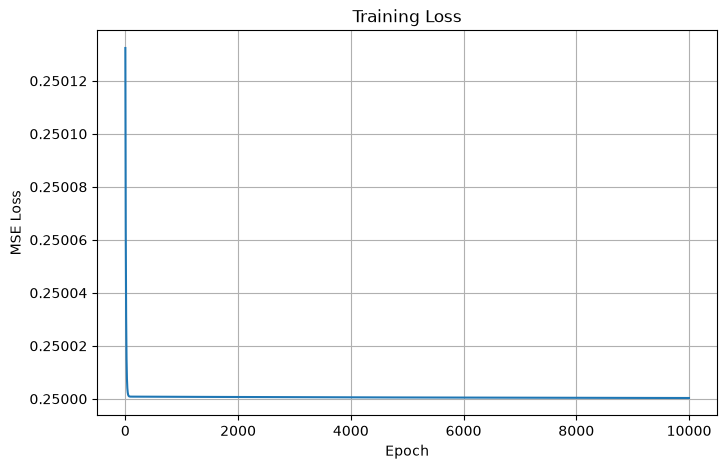

In [114]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()